# Credit Application Analysis

This notebook uses a mock credit application dataset to train a simple machine learning classifier that predicts whether an application is approved.

The workflow covers loading the data, exploring basic quality checks, training a decision tree model, evaluating predictions, and reviewing feature importance.

Matplotlib is building the font cache; this may take a moment.


   Age    Income  LoanAmount  CreditScore  Approved
0   25   30000.0      5000.0          650         1
1   45   80000.0     20000.0          720         1
2   35   50000.0     10000.0          690         1
3   23   20000.0      3000.0          610         0
4   52  120000.0     25000.0          780         1

Data Summary:
                Age         Income    LoanAmount   CreditScore      Approved
count  13053.000000   13053.000000  13053.000000  13053.000000  13053.000000
mean      47.755152   84506.828812  17927.123811    724.534666      0.502643
std       14.198673   30649.329033   7064.822147     47.161195      0.500012
min       23.000000   20000.000000   3000.000000    610.000000      0.000000
25%       36.000000   61873.163307  12710.064142    690.000000      0.000000
50%       48.000000   89638.223166  19109.910440    732.000000      1.000000
75%       60.000000  111174.476734  24074.016887    766.000000      1.000000
max       72.000000  128770.877145  28129.987182    793.0

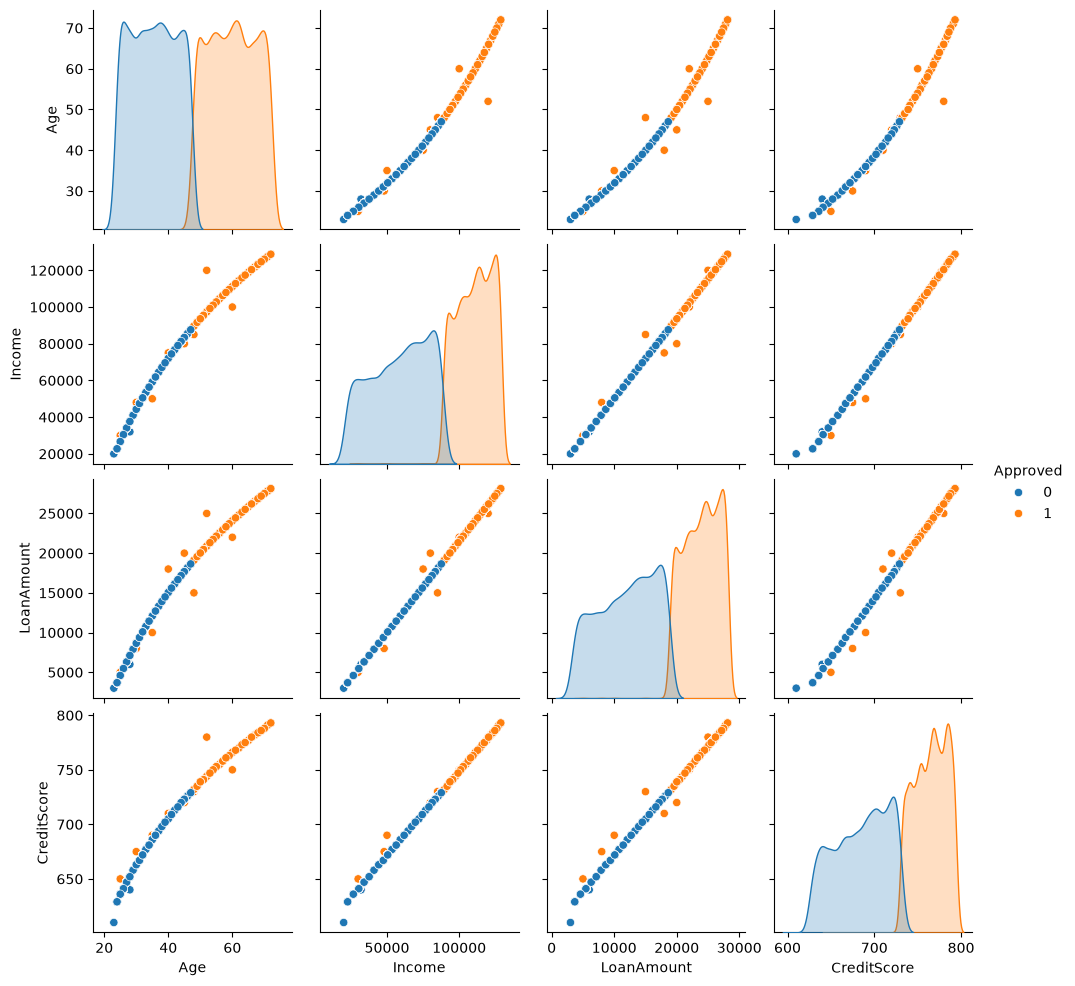


Confusion Matrix:
[[1299    0]
 [   2 1310]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1299
           1       1.00      1.00      1.00      1312

    accuracy                           1.00      2611
   macro avg       1.00      1.00      1.00      2611
weighted avg       1.00      1.00      1.00      2611



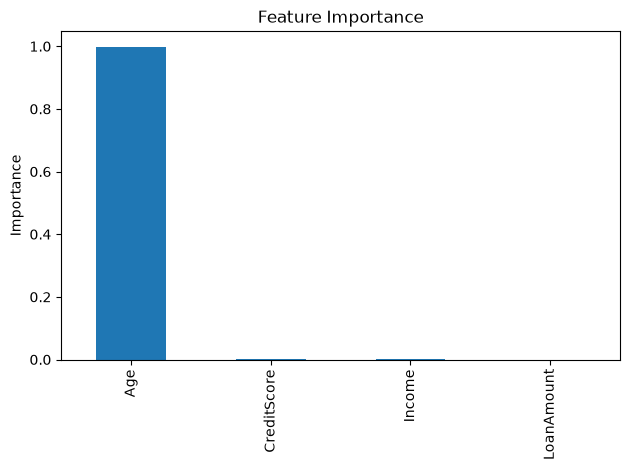

In [1]:
# Step 1: Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Step 2: Load the local dataset
df = pd.read_excel("mock_credit.xlsx")

print(df.head())

# Step 3: Explore the data
print("\nData Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

# Visualize relationships between the numeric features and approval status
sns.pairplot(df, hue="Approved")
plt.show()

# Step 4: Prepare features and target
X = df.drop("Approved", axis=1)
y = df["Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5: Train the machine learning model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Step 6: Evaluate model performance
predictions = model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Step 7: Review feature importance
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(
    kind="bar", title="Feature Importance"
)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

## Notes

This is a learning project using mock data. The model is not intended for real credit decisions, compliance review, or production lending workflows.